# synopsis
- just show the results from the lund_eec.py ...

In [1]:
my_cmaps = ['viridis', 'plasma', 'Greys', 'Greys_r']
# 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── paths ─────────────────────────────────────────────────────────────────────
stem = 'lund_eec_output'   # change to match your --output stem

eec_path         = f'{stem}_eec.parquet'
lund_path        = f'{stem}_lundplane.npy'
lund_xedges_path = f'{stem}_lundplane_xedges.npy'
lund_yedges_path = f'{stem}_lundplane_yedges.npy'

# ── load ──────────────────────────────────────────────────────────────────────
eec_df = pd.read_parquet(eec_path)
h2     = np.load(lund_path)
xedges = np.load(lund_xedges_path)   # ln(1/Δ)
yedges = np.load(lund_yedges_path)   # ln(kt)

jet_pt_min = eec_df['jet_pt_min'].iloc[0]
jet_pt_max = eec_df['jet_pt_max'].iloc[0]
jet_pt_rep = 0.5 * (jet_pt_min + jet_pt_max)

# ── secondary-axis helpers ────────────────────────────────────────────────────
def _log_secaxis(sec, axis, label):
    _ax = getattr(sec, f'{axis}axis')
    _ax.set_major_locator(mticker.LogLocator(base=10, numticks=8))
    _ax.set_major_formatter(mticker.LogFormatterMathtext(labelOnlyBase=False))
    getattr(sec, f'set_{axis}label')(label)

def add_lund_secaxis(ax):
    secx = ax.secondary_xaxis('top',
        functions=(lambda x: np.exp(-np.clip(x, -30, 30)),
                   lambda r: -np.log(np.clip(r, 1e-9, None))))
    _log_secaxis(secx, 'x', r'$\Delta$ [rad]')

def add_lund_secyaxis(ax):
    secy = ax.secondary_yaxis('right',
        functions=(lambda y: np.exp(np.clip(y, -30, 30)),
                   lambda k: np.log(np.clip(k, 1e-9, None))))
    _log_secaxis(secy, 'y', r'$k_t$ [GeV]')

def add_eec_secaxis(ax):
    secx = ax.secondary_xaxis('top',
        functions=(lambda x: np.exp(np.clip(x, -30, 30)),
                   lambda r: np.log(np.clip(r, 1e-9, None))))
    _log_secaxis(secx, 'x', r'$\Delta R$ [rad]')

def add_z_half_line(ax):
    x_arr = np.array([xedges[0], xedges[-1]])
    ax.plot(x_arr, -x_arr + np.log(0.5 * jet_pt_rep),
            color='red', lw=1.5, ls='-', label=r'$z = 0.5$')

def add_jet_pt_legend(ax):
    ax.plot([], [], ' ', label=rf'$p_{{T,\rm jet}} \approx {jet_pt_min:.0f}$ GeV')

# ── bin-width normalisation ───────────────────────────────────────────────────
def _bw_norm(grp, col):
    """Return dE2C/d(ln ΔR): divide by bin width Δ(ln ΔR)."""
    bw = grp['bin_hi'].values - grp['bin_lo'].values
    return grp[col].values / bw

_eec_ylabel = r'$dE2C/d\ln(\Delta R)$'

# ── EEC plot helpers ──────────────────────────────────────────────────────────
eec_types = [('eec_AA', 'A only'), ('eec_BB', 'B only'),
             ('eec_AB', 'A×B cross'), ('eec_all', 'A∪B all')]

def plot_eec(sub_df, suptitle):
    """4-panel EEC plot (one panel per type), one line per label."""
    labels = sorted(sub_df['label'].unique())
    fig, axes = plt.subplots(1, len(eec_types),
                             figsize=(5 * len(eec_types), 4), sharey=True)
    for col, (col_name, title) in enumerate(eec_types):
        ax = axes[col]
        for lbl in labels:
            grp = sub_df[sub_df['label'] == lbl]
            ax.step(grp['ln_dR'], _bw_norm(grp, col_name), where='mid', label=lbl)
        ax.set_title(title)
        ax.set_xlabel(r'$\ln(\Delta R)$')
        if col == 0:
            ax.set_ylabel(_eec_ylabel)
        add_jet_pt_legend(ax)
        ax.legend(fontsize=8)
        add_eec_secaxis(ax)
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

_eec_colors  = {'eec_all': 'black', 'eec_AA': 'tab:blue',
                'eec_BB': 'tab:orange', 'eec_AB': 'tab:green'}
_eec_lstyles = {'eec_all': '-',  'eec_AA': '--', 'eec_BB': '-.', 'eec_AB': ':'}
_eec_names   = {'eec_all': r'A∪B (all)', 'eec_AA': r'A×A',
                'eec_BB': r'B×B',        'eec_AB': r'A×B (cross)'}

def _plot_four(sub_df, suptitle):
    """Overlay all 4 E2C types in one panel per label."""
    labels = sorted(eec_df['label'].unique())
    fig, axes = plt.subplots(1, len(labels), figsize=(6 * len(labels), 5),
                             sharey=True, sharex=True)
    if len(labels) == 1:
        axes = [axes]
    for ax, lbl in zip(axes, labels):
        grp = sub_df[sub_df['label'] == lbl]
        if grp.empty:
            continue
        for col_name in ('eec_all', 'eec_AA', 'eec_BB', 'eec_AB'):
            ax.step(grp['ln_dR'], _bw_norm(grp, col_name), where='mid',
                    label=_eec_names[col_name],
                    color=_eec_colors[col_name], ls=_eec_lstyles[col_name])
        ax.set_title(lbl)
        ax.set_xlabel(r'$\ln(\Delta R)$')
        if ax is axes[0]:
            ax.set_ylabel(_eec_ylabel)
        add_jet_pt_legend(ax)
        ax.legend(fontsize=9)
        add_eec_secaxis(ax)
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

# ── summary ───────────────────────────────────────────────────────────────────
print("columns:", eec_df.columns.tolist())
print()
summary = (eec_df[['selection', 'label', 'kt_cut', 'kappa_cut', 'n_jets', 'n_splits']]
           .drop_duplicates()
           .sort_values(['label', 'selection', 'kt_cut']))
print(summary.to_string(index=False))


columns: ['ln_dR', 'bin_lo', 'bin_hi', 'eec_AA', 'eec_BB', 'eec_AB', 'eec_all', 'n_jets', 'n_splits', 'avg_kt', 'label', 'kt_cut', 'kappa_cut', 'selection', 'jet_pt_min', 'jet_pt_max']

      selection label  kt_cut  kappa_cut  n_jets  n_splits
         max_kt   ppB     NaN        NaN    1993      1993
  max_kt_kt>0.0   ppB     0.0        0.0    1993      1993
  max_kt_kt>1.0   ppB     1.0        0.0    1993      1933
  max_kt_kt>2.0   ppB     2.0        0.0    1993      1616
soft_drop_z>0.1   ppB     NaN        NaN    1993      1989
soft_drop_z>0.2   ppB     NaN        NaN    1993      1950
soft_drop_z>0.3   ppB     NaN        NaN    1993      1775
symmetric_z>0.3   ppB     NaN        NaN    1993      3654
      threshold   ppB     0.0        0.0    1993     22084
      threshold   ppB     1.0        0.0    1993      6773
      threshold   ppB     2.0        0.0    1993      3032


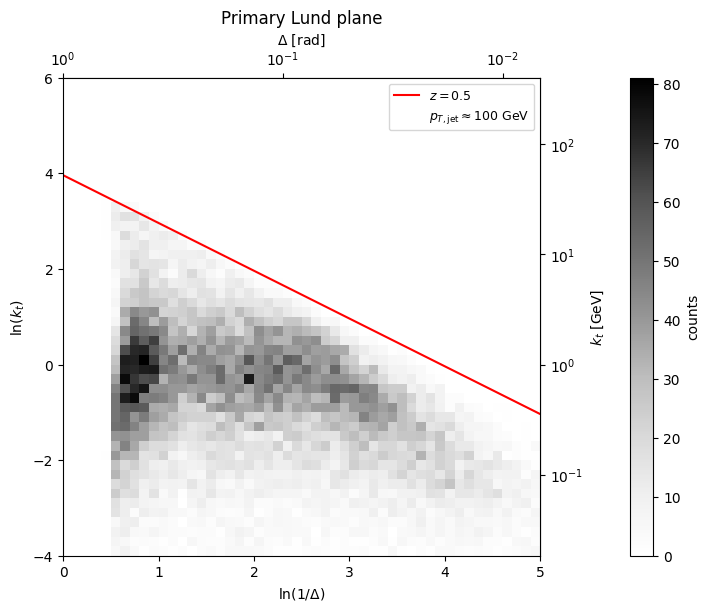

In [3]:
# ── Lund plane (density) ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6), layout='constrained')
Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc, indexing='ij')
pcm = ax.pcolormesh(X, Y, h2, cmap=my_cmaps[2], shading='auto')
plt.colorbar(pcm, ax=ax, label='counts')
ax.set_xlabel(r'$\ln(1/\Delta)$')
ax.set_ylabel(r'$\ln(k_t)$')
ax.set_title('Primary Lund plane')
add_z_half_line(ax)
add_jet_pt_legend(ax)
ax.legend(fontsize=9, loc='upper right')
add_lund_secaxis(ax)
add_lund_secyaxis(ax)
plt.show()


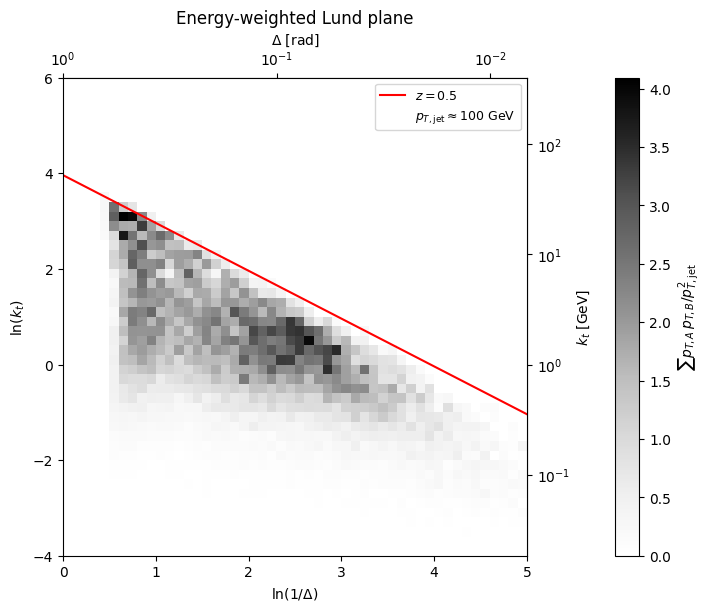

In [4]:
# ── energy-weighted Lund plane ────────────────────────────────────────────────
h2w = np.load(f'{stem}_lundplane_weighted.npy')

fig, ax = plt.subplots(figsize=(7, 6), layout='constrained')
Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc, indexing='ij')
pcm = ax.pcolormesh(X, Y, h2w, cmap=my_cmaps[2], shading='auto')
plt.colorbar(pcm, ax=ax, label=r'$\sum p_{T,A}\,p_{T,B}/p_{T,\mathrm{jet}}^2$')
ax.set_xlabel(r'$\ln(1/\Delta)$')
ax.set_ylabel(r'$\ln(k_t)$')
ax.set_title('Energy-weighted Lund plane')
add_z_half_line(ax)
add_jet_pt_legend(ax)
ax.legend(fontsize=9, loc='upper right')
add_lund_secaxis(ax)
add_lund_secyaxis(ax)
plt.show()


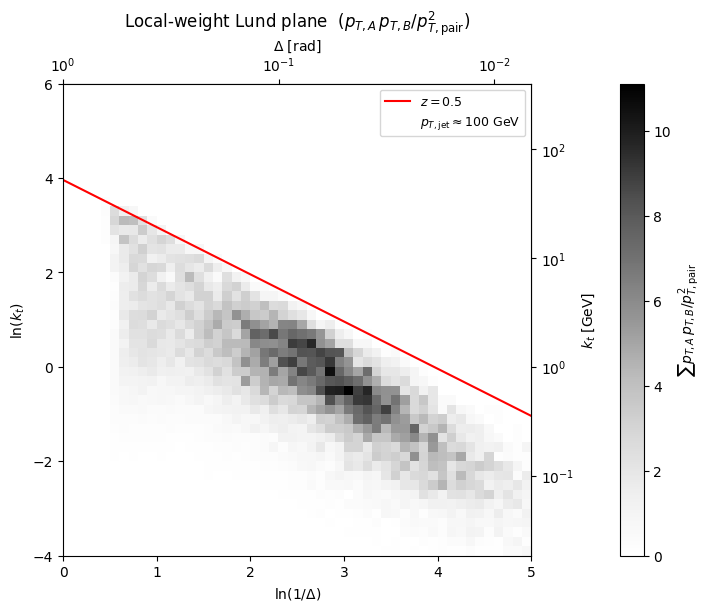

In [5]:
# ── local-weight Lund plane (pT_A * pT_B / pT_pair²) ─────────────────────────
lw_path = f'{stem}_lundplane_localweighted.npy'
import os as _os
if not _os.path.exists(lw_path):
    print(f'No local-weight Lund plane found ({lw_path}). Run with --lund-local-weight.')
else:
    h2lw = np.load(lw_path)
    fig, ax = plt.subplots(figsize=(7, 6), layout='constrained')
    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc, indexing='ij')
    pcm = ax.pcolormesh(X, Y, h2lw, cmap=my_cmaps[2], shading='auto')
    plt.colorbar(pcm, ax=ax, label=r'$\sum p_{T,A}\,p_{T,B}/p_{T,\mathrm{pair}}^2$')
    ax.set_xlabel(r'$\ln(1/\Delta)$')
    ax.set_ylabel(r'$\ln(k_t)$')
    ax.set_title(r'Local-weight Lund plane  ($p_{T,A}\,p_{T,B}/p_{T,\rm pair}^2$)')
    add_z_half_line(ax)
    add_jet_pt_legend(ax)
    ax.legend(fontsize=9, loc='upper right')
    add_lund_secaxis(ax)
    add_lund_secyaxis(ax)
    plt.show()


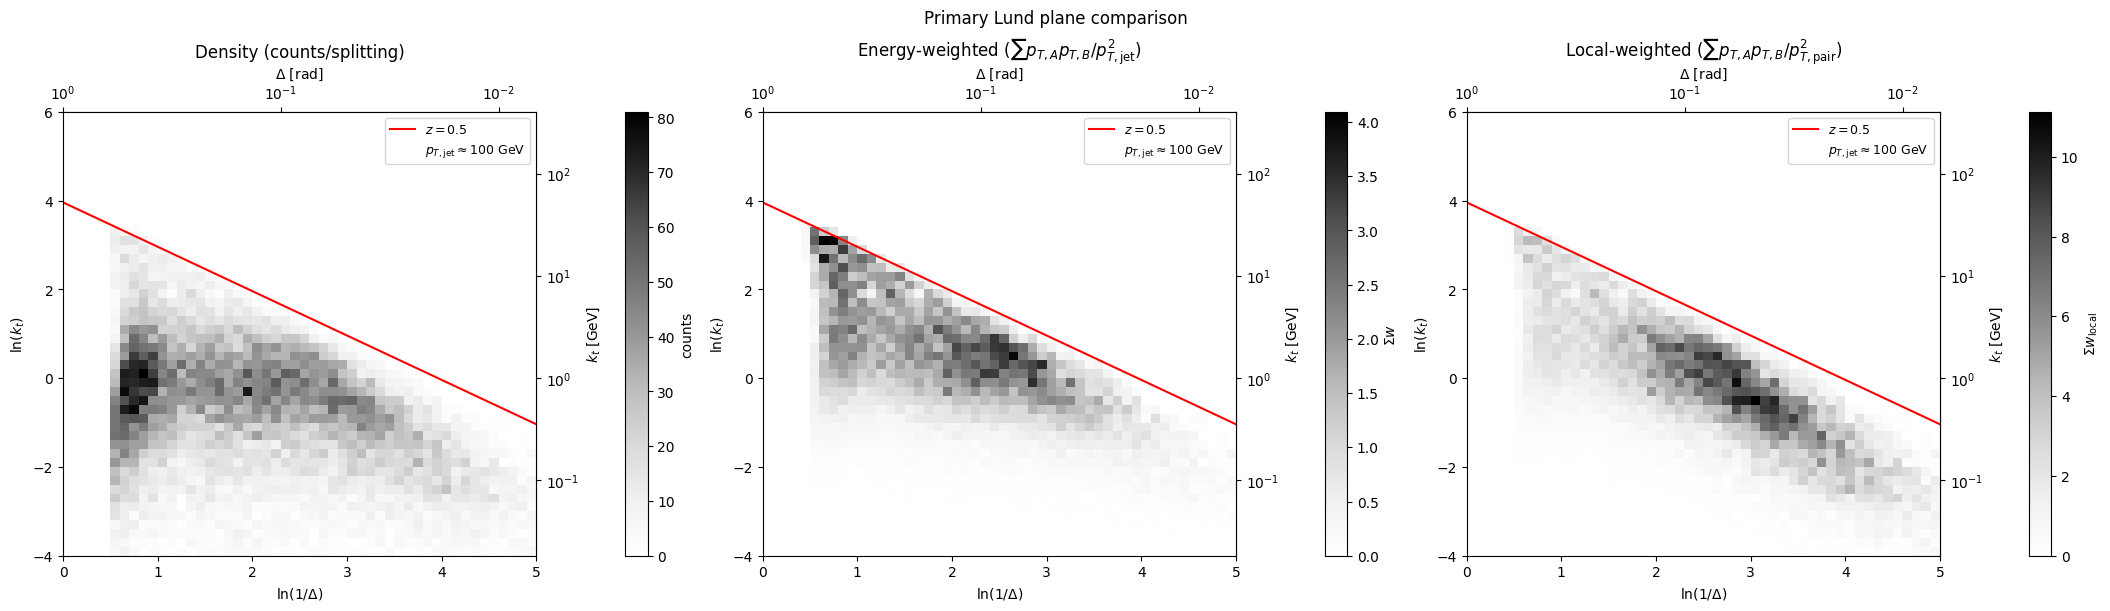

In [6]:
# ── density vs energy-weighted vs local-weighted Lund plane side by side ──────
lw_path = f'{stem}_lundplane_localweighted.npy'
import os as _os
panels = [
    (h2,  'Density (counts/splitting)',                                  'counts'),
    (h2w, r'Energy-weighted ($\sum p_{T,A}p_{T,B}/p_{T,\rm jet}^2$)',   r'$\Sigma w$'),
]
if _os.path.exists(lw_path):
    h2lw = np.load(lw_path)
    panels.append((h2lw, r'Local-weighted ($\sum p_{T,A}p_{T,B}/p_{T,\rm pair}^2$)', r'$\Sigma w_{\rm local}$'))

Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc, indexing='ij')

fig, axes = plt.subplots(1, len(panels), figsize=(7 * len(panels), 6), layout='constrained')
for ax, (data, title, cbar_label) in zip(axes, panels):
    pcm = ax.pcolormesh(X, Y, data, cmap=my_cmaps[2], shading='auto')
    plt.colorbar(pcm, ax=ax, label=cbar_label)
    ax.set_xlabel(r'$\ln(1/\Delta)$')
    ax.set_ylabel(r'$\ln(k_t)$')
    ax.set_title(title)
    add_z_half_line(ax)
    add_jet_pt_legend(ax)
    ax.legend(fontsize=9, loc='upper right')
    add_lund_secaxis(ax)
    add_lund_secyaxis(ax)

plt.suptitle('Primary Lund plane comparison')
plt.show()


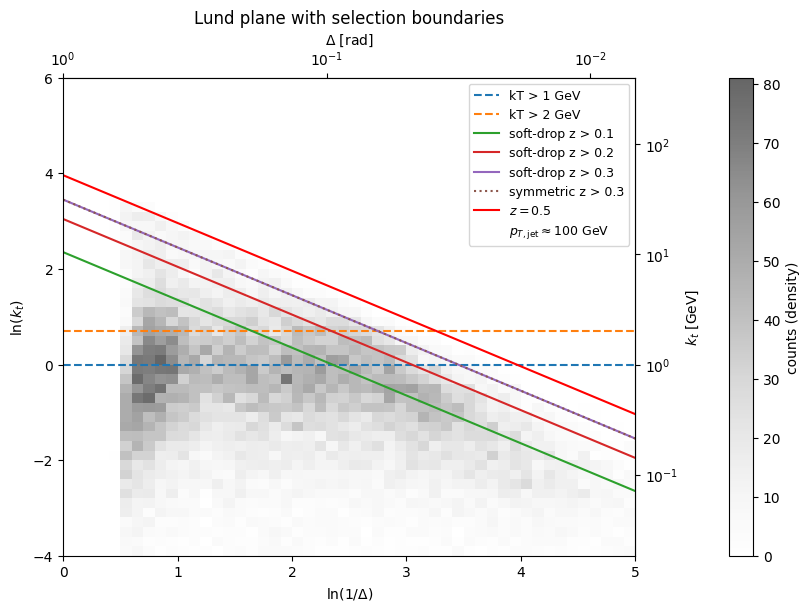

In [7]:
# ── Lund plane with selection region boundaries ───────────────────────────────
x_arr = np.linspace(xedges[0], xedges[-1], 200)  # ln(1/Δ)

fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')
pcm = ax.pcolormesh(X, Y, h2, cmap=my_cmaps[2], shading='auto', alpha=0.6)
plt.colorbar(pcm, ax=ax, label='counts (density)')

colors_sel = plt.cm.tab10.colors
ci = 0

# kT threshold lines
kt_cuts_present = sorted(eec_df.loc[eec_df['selection'] == 'threshold', 'kt_cut'].dropna().unique())
for kt in kt_cuts_present:
    if kt > 0:
        ax.axhline(np.log(kt), ls='--', color=colors_sel[ci % 10],
                   label=f'kT > {kt:.0f} GeV')
        ci += 1

# soft-drop boundaries
for sel in eec_df['selection'].unique():
    if sel.startswith('soft_drop_z>'):
        z_sd = float(sel.split('>')[-1])
        c = np.log(z_sd * jet_pt_rep)
        ax.plot(x_arr, -x_arr + c, ls='-', color=colors_sel[ci % 10],
                label=f'soft-drop z > {z_sd}')
        ci += 1

# symmetric boundaries
for sel in eec_df['selection'].unique():
    if sel.startswith('symmetric_z>'):
        z_sym = float(sel.split('>')[-1])
        c = np.log(z_sym * jet_pt_rep)
        ax.plot(x_arr, -x_arr + c, ls=':', color=colors_sel[ci % 10],
                label=f'symmetric z > {z_sym}')
        ci += 1

add_z_half_line(ax)
add_jet_pt_legend(ax)

ax.set_xlabel(r'$\ln(1/\Delta)$')
ax.set_ylabel(r'$\ln(k_t)$')
ax.set_title('Lund plane with selection boundaries')
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])
ax.legend(fontsize=9, loc='upper right')
add_lund_secaxis(ax)
add_lund_secyaxis(ax)
plt.show()


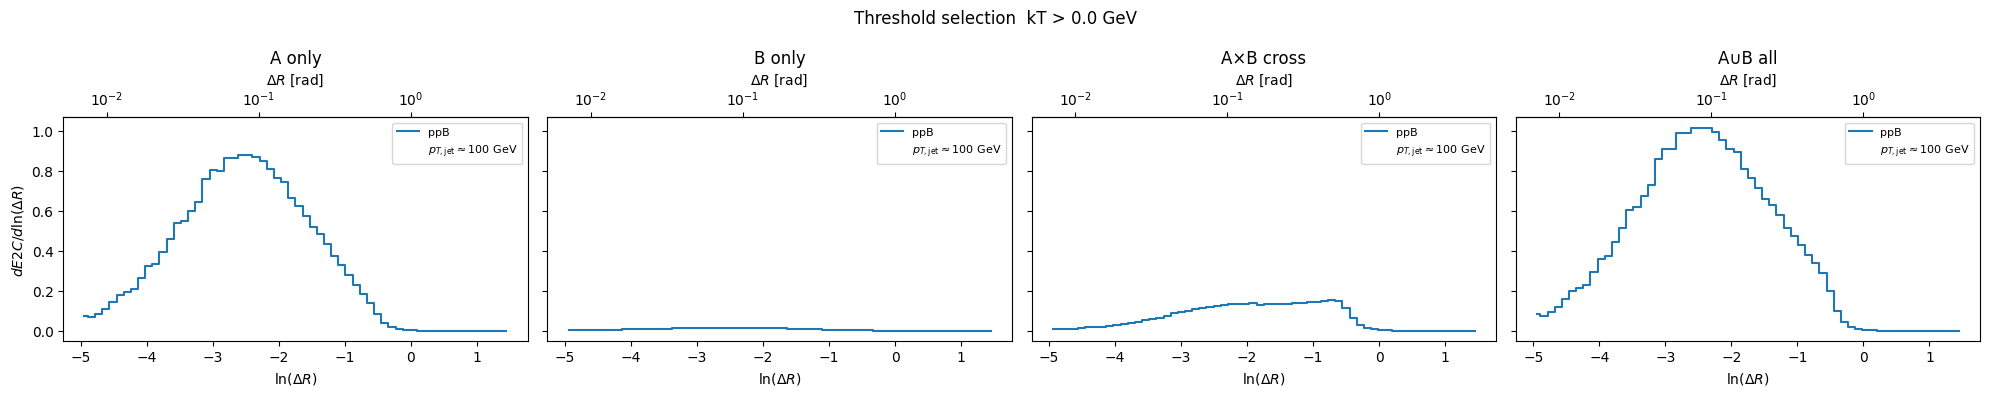

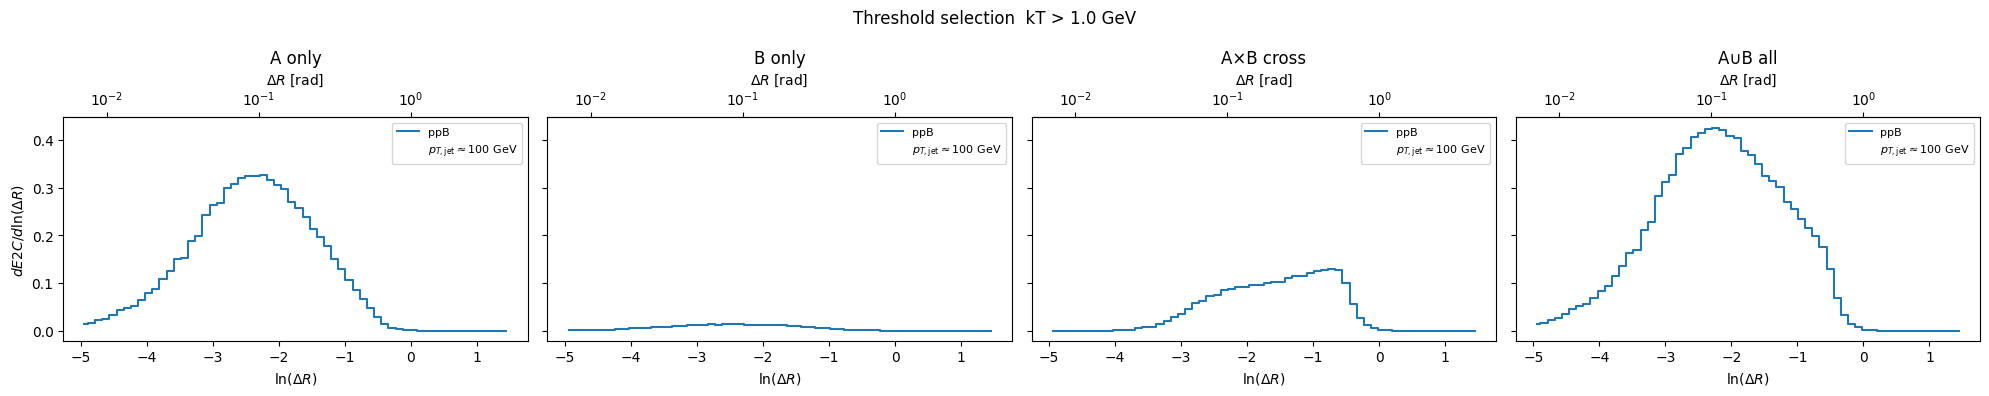

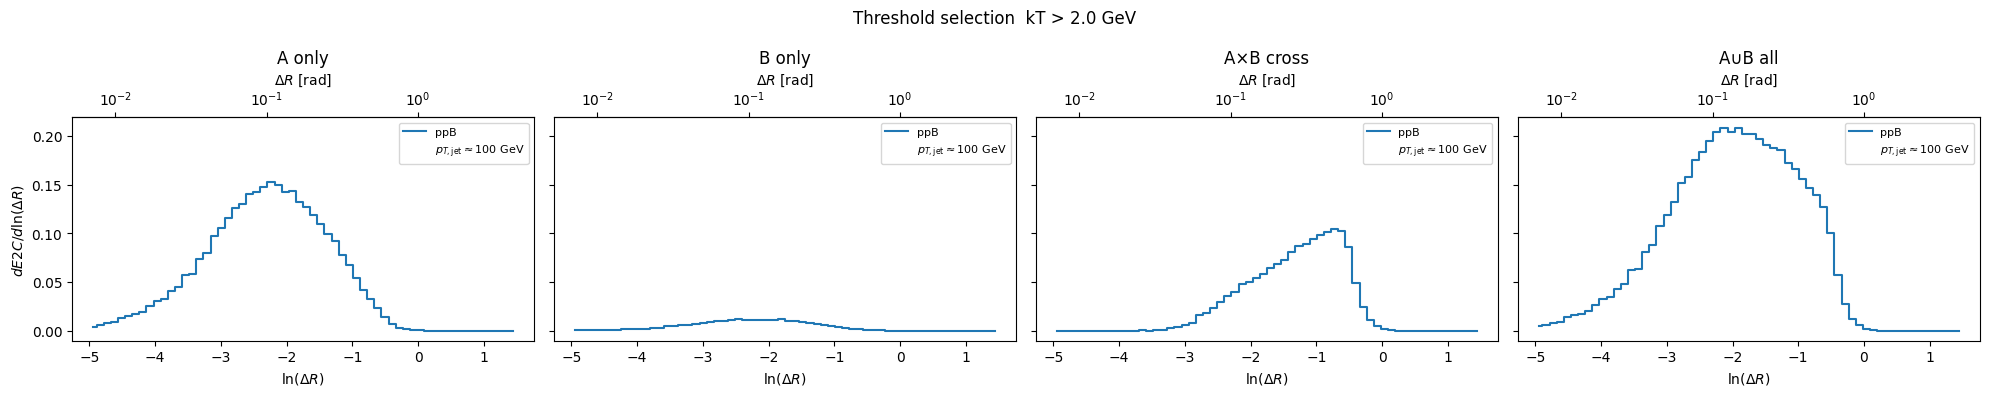

In [8]:
# ── threshold-based EEC: one plot per kT cut ──────────────────────────────────
thr = eec_df[eec_df['selection'] == 'threshold']
for kt, grp in thr.groupby('kt_cut'):
    plot_eec(grp, f'Threshold selection  kT > {kt} GeV')


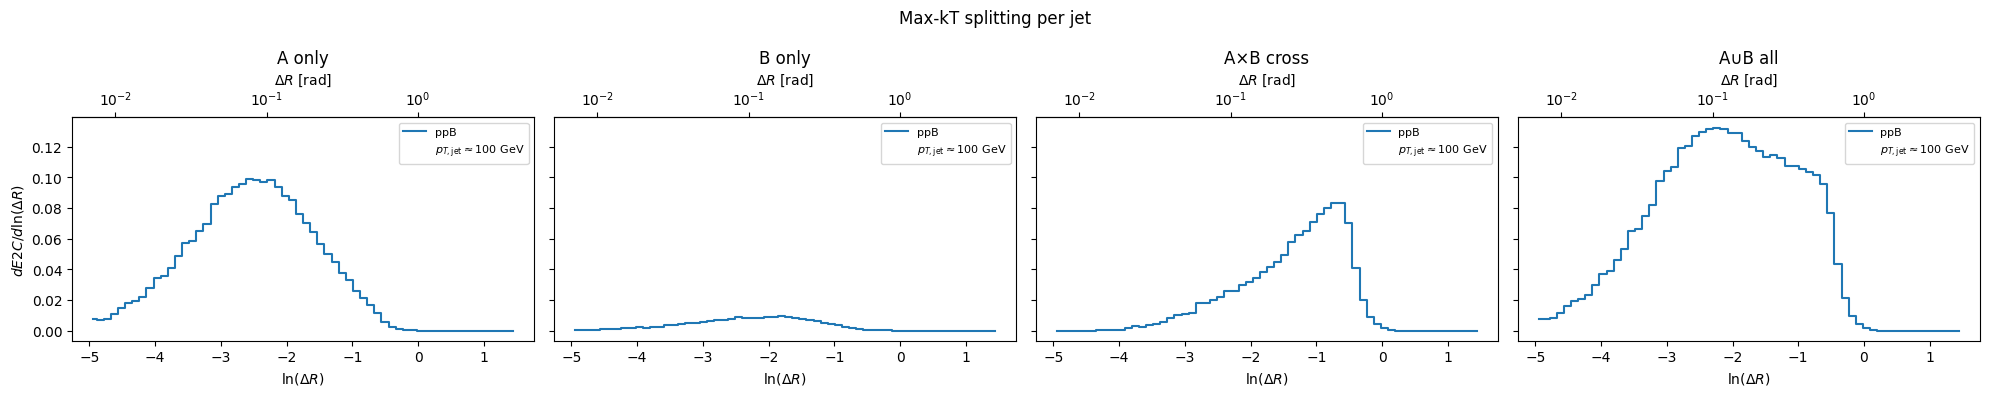

In [9]:
# ── max-kT splitting ──────────────────────────────────────────────────────────
maxkt = eec_df[eec_df['selection'] == 'max_kt']
if maxkt.empty:
    print("No max-kT data (run with --max-kt-eec)")
else:
    plot_eec(maxkt, 'Max-kT splitting per jet')


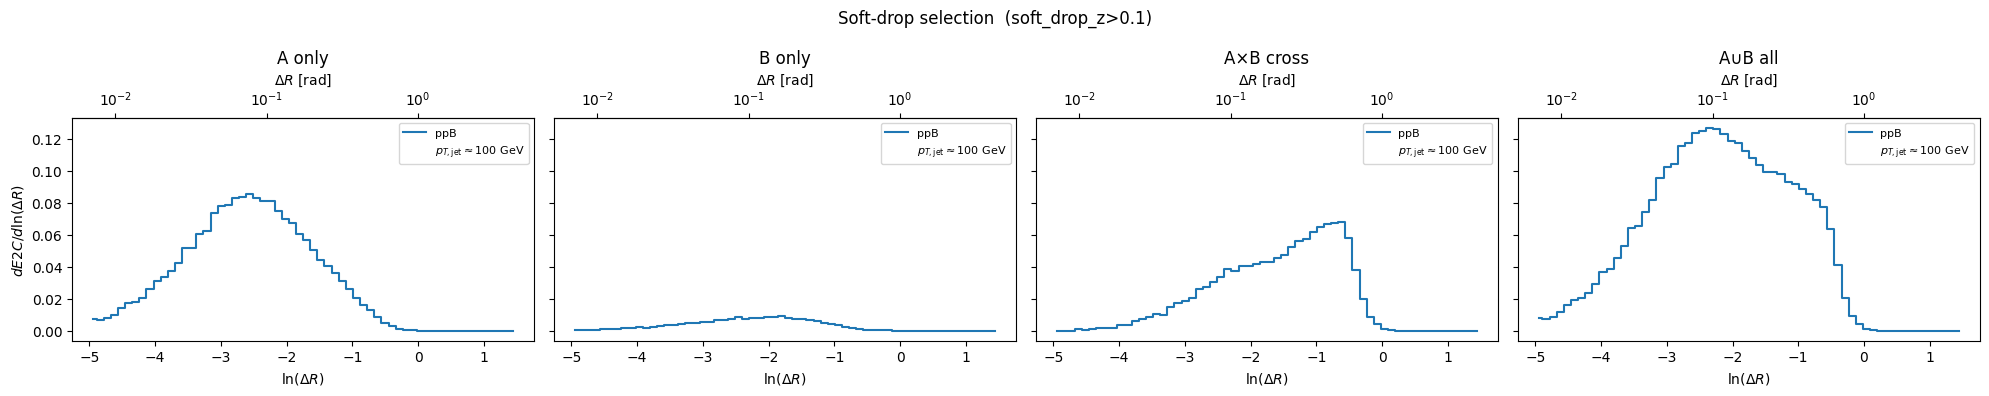

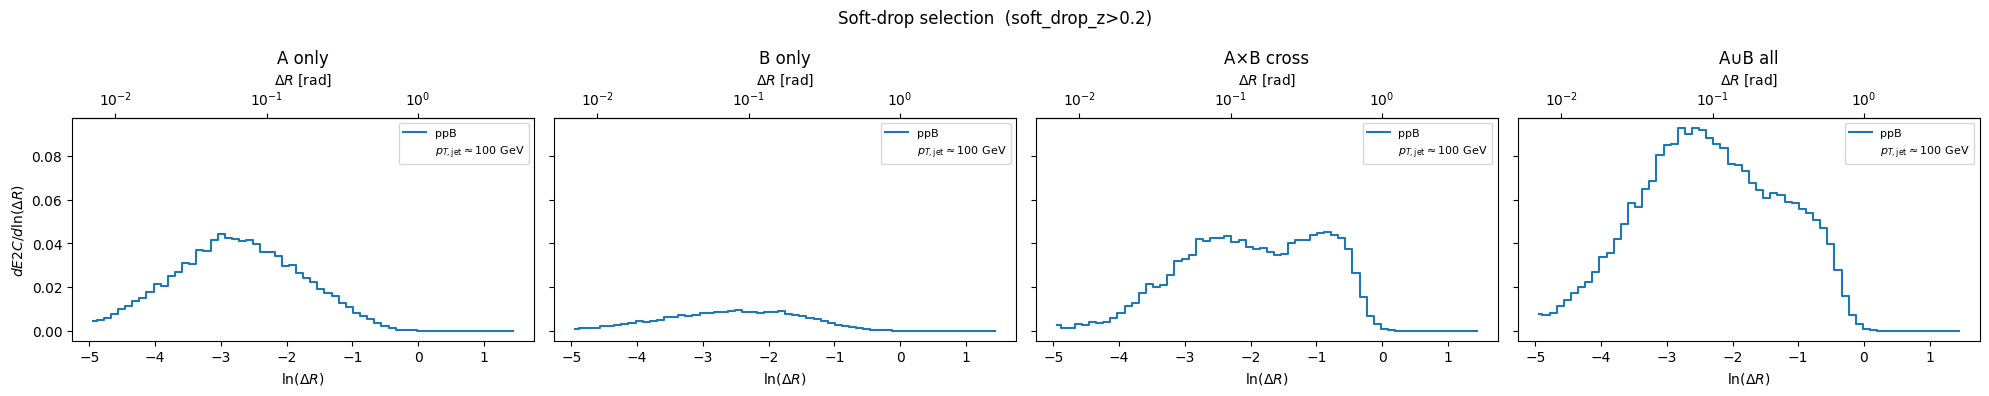

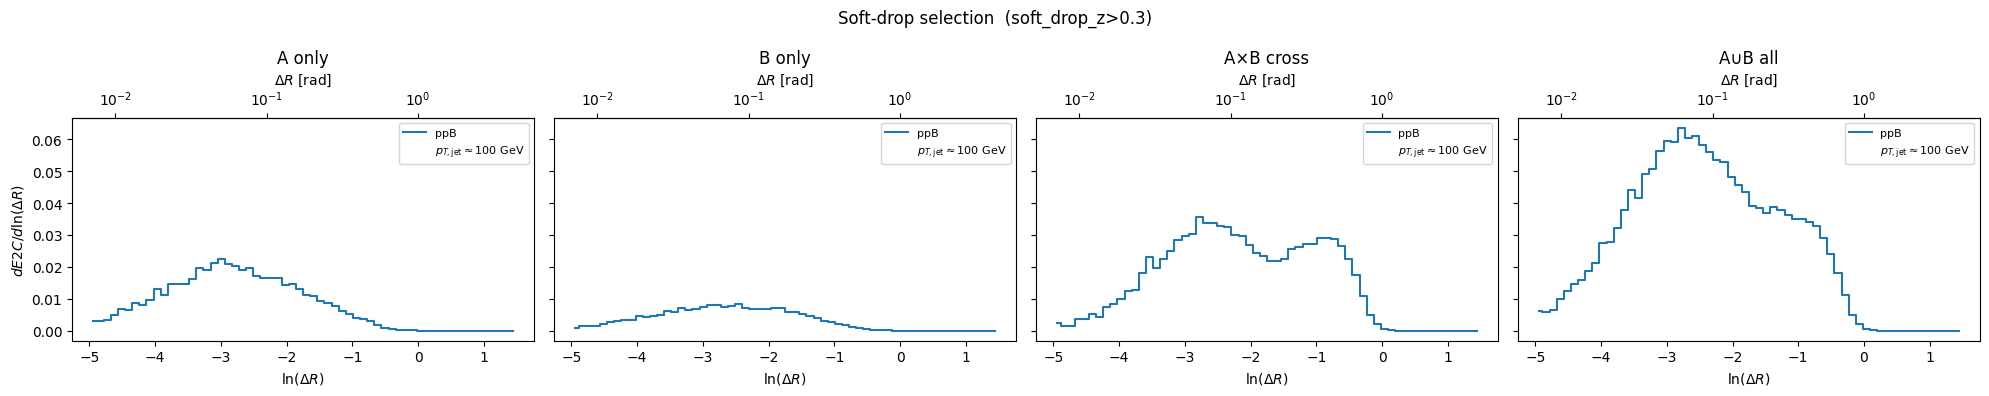

In [10]:
# ── soft-drop splitting ───────────────────────────────────────────────────────
sd_sels = [s for s in eec_df['selection'].unique() if s.startswith('soft_drop')]
if not sd_sels:
    print("No soft-drop data (run with --soft-drop-eec)")
else:
    for sel in sd_sels:
        sd = eec_df[eec_df['selection'] == sel]
        plot_eec(sd, f'Soft-drop selection  ({sel})')


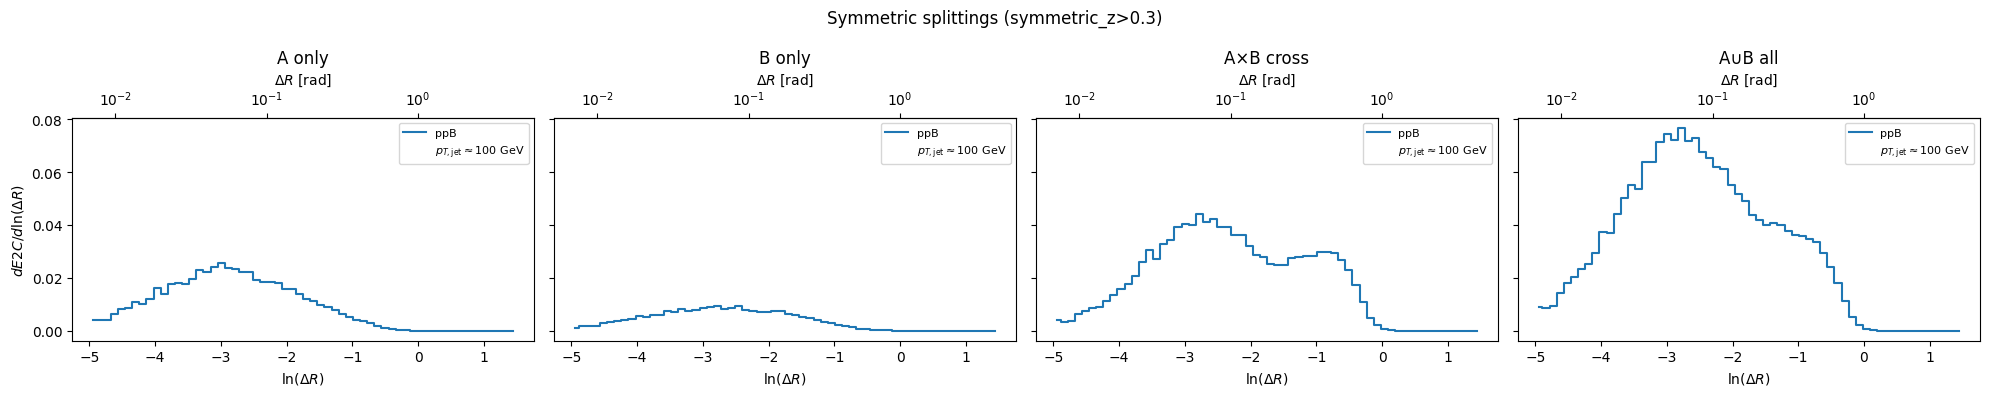

In [11]:
# ── symmetric splittings (z > z_sym) ─────────────────────────────────────────
sym_sels = [s for s in eec_df['selection'].unique() if s.startswith('symmetric')]
if not sym_sels:
    print("No symmetric-splitting data (run with --symmetric-eec)")
else:
    for sel in sym_sels:
        sym = eec_df[eec_df['selection'] == sel]
        plot_eec(sym, f'Symmetric splittings ({sel})')


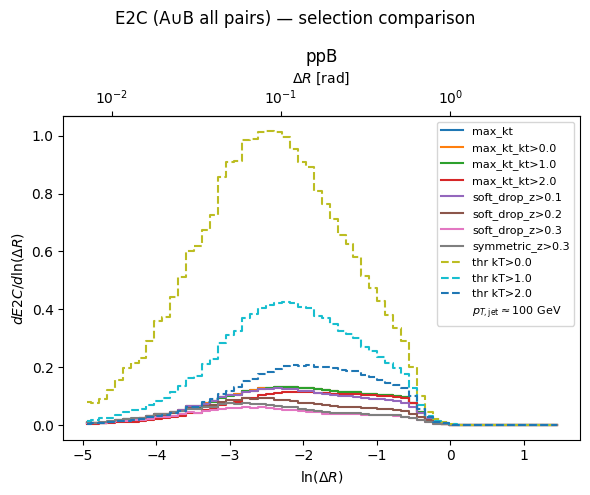

In [12]:
# ── comparison: eec_all across all selections for each label ──────────────────
labels     = sorted(eec_df['label'].unique())
selections = sorted(eec_df['selection'].unique())

fig, axes = plt.subplots(1, len(labels), figsize=(6 * len(labels), 5), sharey=True)
if len(labels) == 1:
    axes = [axes]

for ax, lbl in zip(axes, labels):
    sub = eec_df[eec_df['label'] == lbl]
    for sel in selections:
        grp = sub[sub['selection'] == sel]
        if grp.empty:
            continue
        if sel == 'threshold':
            for (kt, kp), kgrp in grp.groupby(['kt_cut', 'kappa_cut']):
                leg = f'thr kT>{kt}'
                if kp > 0:
                    leg += f' κ>{kp}'
                ax.step(kgrp['ln_dR'], _bw_norm(kgrp, 'eec_all'), where='mid',
                        label=leg, ls='--')
        else:
            ax.step(grp['ln_dR'], _bw_norm(grp, 'eec_all'), where='mid', label=sel)
    ax.set_title(lbl)
    ax.set_xlabel(r'$\ln(\Delta R)$')
    ax.set_ylabel(_eec_ylabel)
    add_jet_pt_legend(ax)
    ax.legend(fontsize=8)
    add_eec_secaxis(ax)

plt.suptitle('E2C (A∪B all pairs) — selection comparison')
plt.tight_layout()
plt.show()


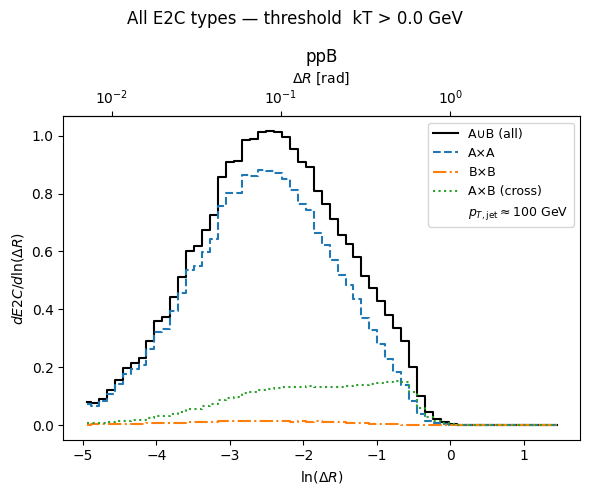

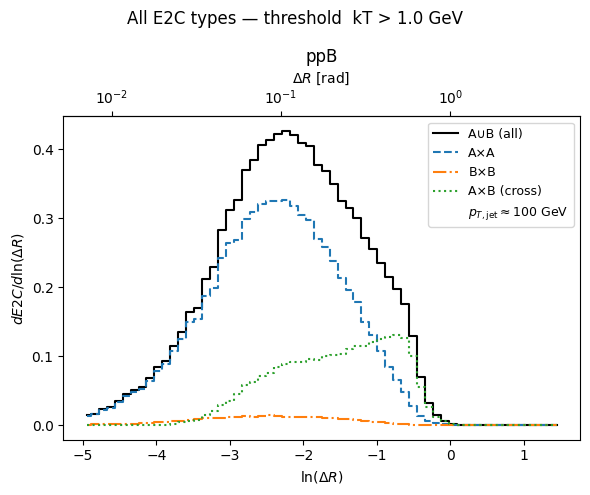

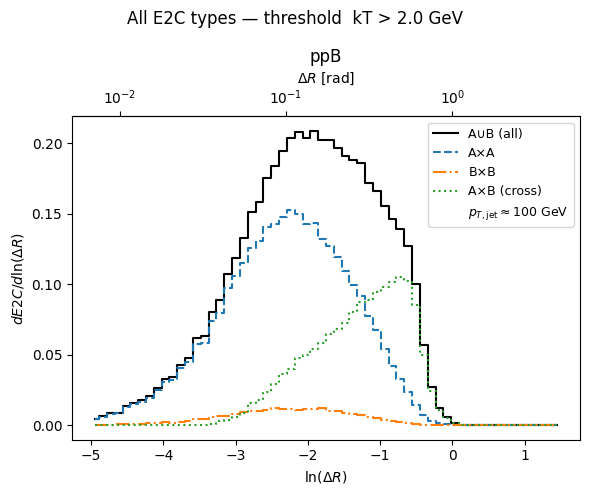

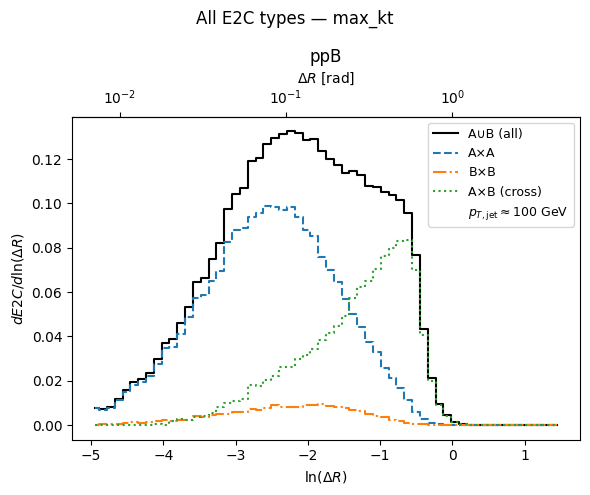

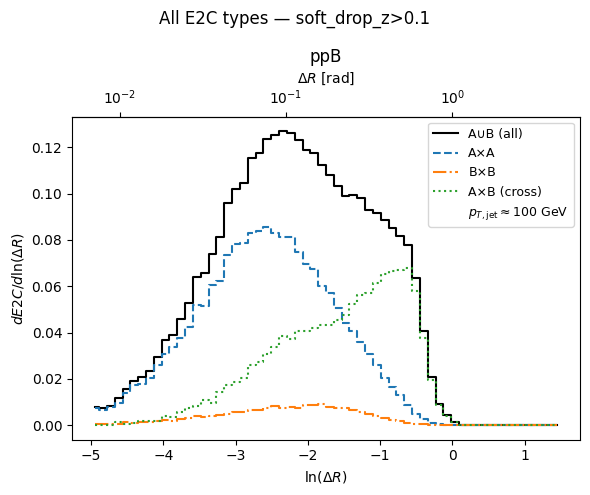

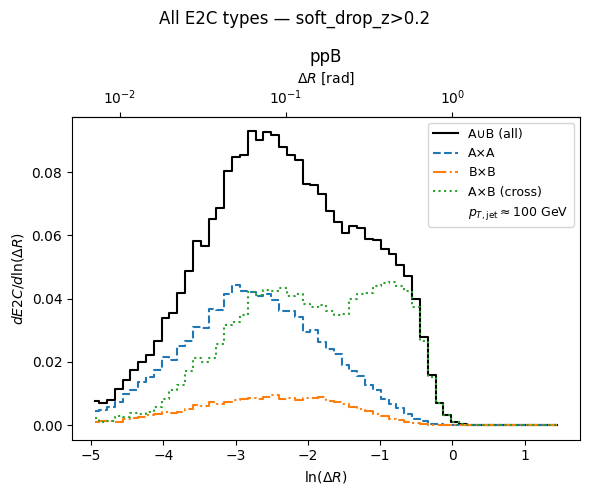

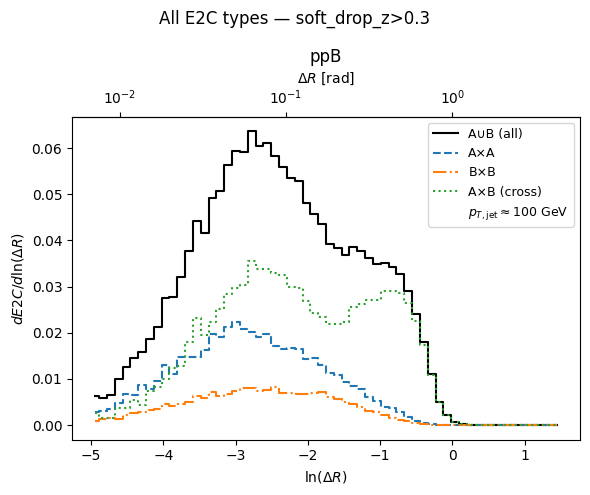

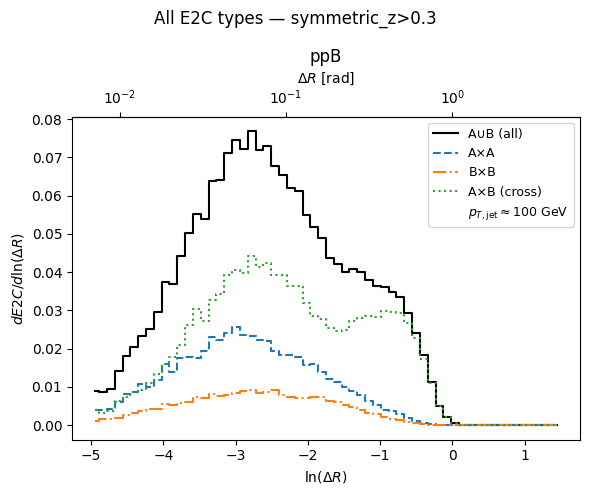

In [13]:
# ── all 4 E2C types overlaid — one plot per (selection × kt_cut × label) ──────
thr = eec_df[eec_df['selection'] == 'threshold']
for (kt, kp), grp in thr.groupby(['kt_cut', 'kappa_cut']):
    title = f'All E2C types — threshold  kT > {kt} GeV'
    if kp > 0:
        title += f',  κ > {kp}'
    _plot_four(grp, title)

# other named selections (max_kt, soft_drop, symmetric) — exclude combined max_kt_kt> (handled below)
for sel in sorted(s for s in eec_df['selection'].unique()
                  if s not in ('threshold',) and not s.startswith('max_kt_kt>')):
    _plot_four(eec_df[eec_df['selection'] == sel], f'All E2C types — {sel}')


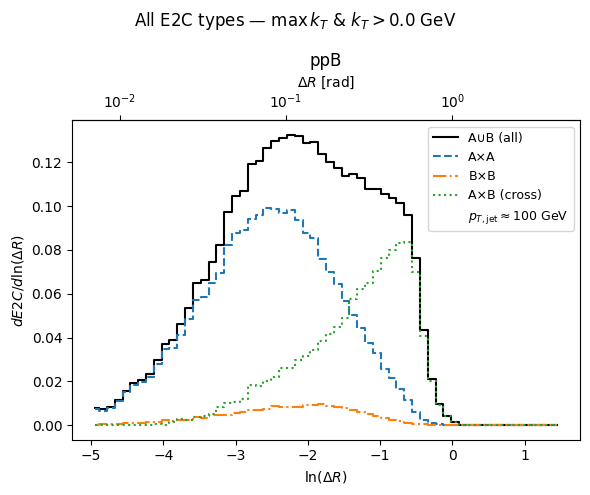

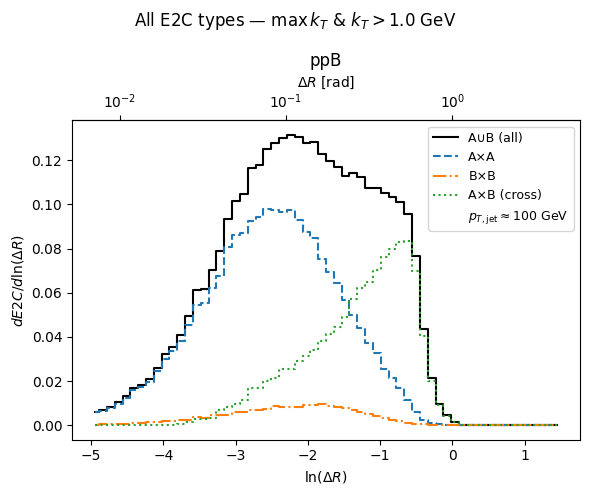

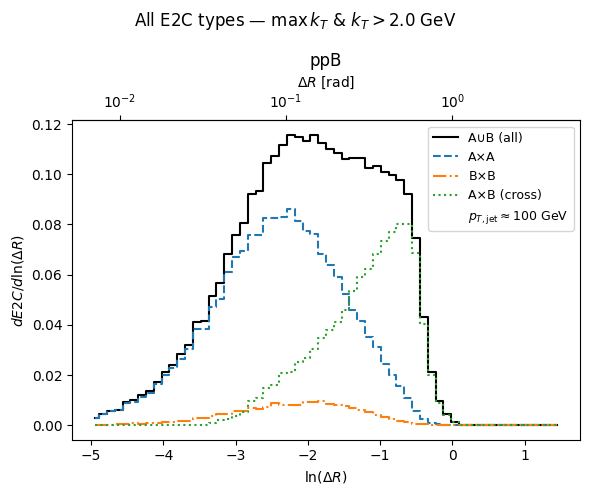

In [14]:
# ── max-kT AND kT>cut combined: one plot per kt_cut ──────────────────────────
maxkt_thr_sels = sorted(s for s in eec_df['selection'].unique() if s.startswith('max_kt_kt>'))
if not maxkt_thr_sels:
    print("No max-kT+threshold data (run with --max-kt-eec and --kt-cuts)")
else:
    for sel in maxkt_thr_sels:
        sub = eec_df[eec_df['selection'] == sel]
        kt_val = sel.split('>')[-1]
        _plot_four(sub, rf'All E2C types — max$\,k_T$ & $k_T > {kt_val}$ GeV')


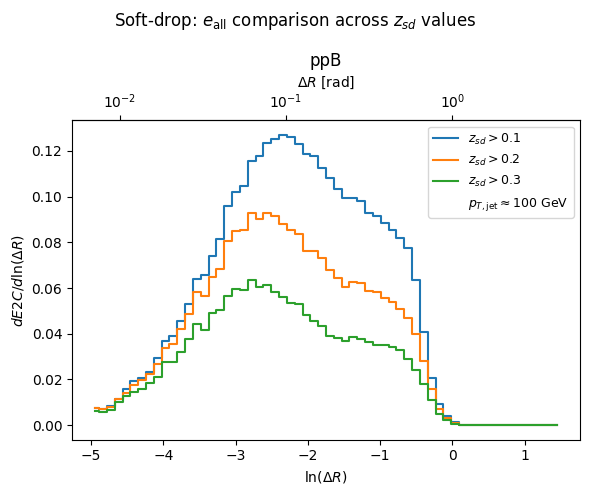

In [15]:
# ── soft-drop: eec_all comparison across z_sd values ─────────────────────────
sd_sels = sorted(s for s in eec_df['selection'].unique() if s.startswith('soft_drop'))
if len(sd_sels) < 2:
    print("Only one (or no) soft-drop selection — run with --z-sd 0.1,0.2,0.3 for comparison")
else:
    labels = sorted(eec_df['label'].unique())
    fig, axes = plt.subplots(1, len(labels), figsize=(6 * len(labels), 5), sharey=True)
    if len(labels) == 1:
        axes = [axes]
    colors = plt.cm.tab10.colors
    for ax, lbl in zip(axes, labels):
        for ci, sel in enumerate(sd_sels):
            grp = eec_df[(eec_df['selection'] == sel) & (eec_df['label'] == lbl)]
            if grp.empty:
                continue
            z_val = sel.split('>')[-1]
            ax.step(grp['ln_dR'], _bw_norm(grp, 'eec_all'), where='mid',
                    label=rf'$z_{{sd}} > {z_val}$', color=colors[ci % 10])
        ax.set_title(lbl)
        ax.set_xlabel(r'$\ln(\Delta R)$')
        if ax is axes[0]:
            ax.set_ylabel(_eec_ylabel)
        add_jet_pt_legend(ax)
        ax.legend(fontsize=9)
        add_eec_secaxis(ax)
    plt.suptitle(r'Soft-drop: $e_{\rm all}$ comparison across $z_{sd}$ values')
    plt.tight_layout()
    plt.show()


In [16]:
# ── symmetric splittings: eec_all comparison with/without kT cut ─────────────
sym_sels = sorted(s for s in eec_df['selection'].unique() if s.startswith('symmetric'))
if len(sym_sels) < 2:
    print("Only one (or no) symmetric selection — run with --z-sym-kt-cut X to add kT threshold")
else:
    labels = sorted(eec_df['label'].unique())
    fig, axes = plt.subplots(1, len(labels), figsize=(6 * len(labels), 5), sharey=True)
    if len(labels) == 1:
        axes = [axes]
    colors = plt.cm.tab10.colors
    for ax, lbl in zip(axes, labels):
        for ci, sel in enumerate(sym_sels):
            grp = eec_df[(eec_df['selection'] == sel) & (eec_df['label'] == lbl)]
            if grp.empty:
                continue
            parts = sel.replace('symmetric_z>', '').split('_kt>')
            z_val = parts[0]
            kt_part = rf', $k_T > {parts[1]}$ GeV' if len(parts) > 1 else ''
            ax.step(grp['ln_dR'], _bw_norm(grp, 'eec_all'), where='mid',
                    label=rf'$z_{{sym}} > {z_val}${kt_part}', color=colors[ci % 10])
        ax.set_title(lbl)
        ax.set_xlabel(r'$\ln(\Delta R)$')
        if ax is axes[0]:
            ax.set_ylabel(_eec_ylabel)
        add_jet_pt_legend(ax)
        ax.legend(fontsize=9)
        add_eec_secaxis(ax)
    plt.suptitle(r'Symmetric splittings: $e_{\rm all}$ with/without $k_T$ cut')
    plt.tight_layout()
    plt.show()


Only one (or no) symmetric selection — run with --z-sym-kt-cut X to add kT threshold


avg_kt per selection:
      selection label  kt_cut   avg_kt  n_splits
         max_kt   ppB     NaN 5.922541      1993
  max_kt_kt>0.0   ppB     0.0 5.922541      1993
  max_kt_kt>1.0   ppB     1.0 6.081127      1933
  max_kt_kt>2.0   ppB     2.0 6.970208      1616
soft_drop_z>0.1   ppB     NaN 5.483906      1989
soft_drop_z>0.2   ppB     NaN 4.885458      1950
soft_drop_z>0.3   ppB     NaN 4.053699      1775
symmetric_z>0.3   ppB     NaN 2.334489      3654
      threshold   ppB     0.0 1.200906     22084
      threshold   ppB     1.0 3.087025      6773
      threshold   ppB     2.0 5.165037      3032


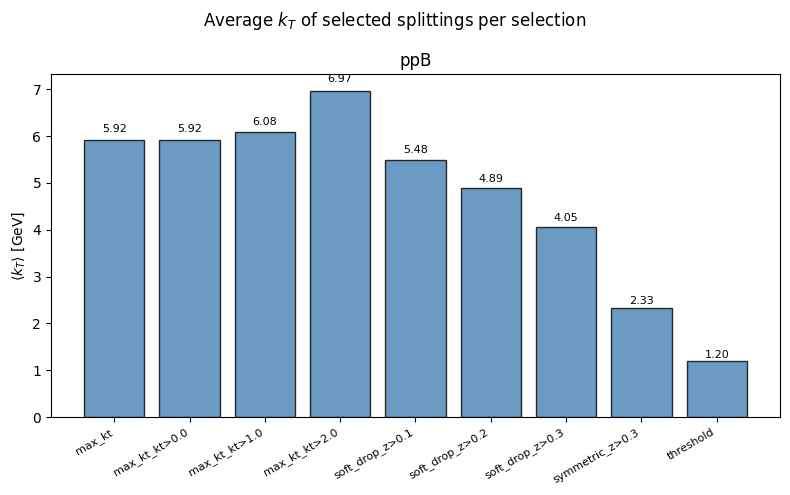

In [17]:
# ── avg_kt per selection ───────────────────────────────────────────────────────
if 'avg_kt' not in eec_df.columns:
    print("No avg_kt column — re-run lund_eec.py to regenerate parquet")
else:
    summary_kt = (eec_df[['selection', 'label', 'kt_cut', 'avg_kt', 'n_splits']]
                  .drop_duplicates()
                  .sort_values(['label', 'selection', 'kt_cut']))
    print("avg_kt per selection:")
    print(summary_kt.to_string(index=False))

    labels = sorted(eec_df['label'].unique())
    fig, axes = plt.subplots(1, len(labels), figsize=(max(8, 3 * len(labels)), 5))
    if len(labels) == 1:
        axes = [axes]
    for ax, lbl in zip(axes, labels):
        sub = summary_kt[summary_kt['label'] == lbl].drop_duplicates('selection')
        sels = sub['selection'].tolist()
        vals = sub['avg_kt'].tolist()
        bars = ax.bar(range(len(sels)), vals, color='steelblue', edgecolor='k', alpha=0.8)
        ax.set_xticks(range(len(sels)))
        ax.set_xticklabels(sels, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel(r'$\langle k_T \rangle$ [GeV]')
        ax.set_title(lbl)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v * 1.02, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=8)
    plt.suptitle(r'Average $k_T$ of selected splittings per selection')
    plt.tight_layout()
    plt.show()
